# Keras and Tensorflow

## What the heck is a tensor?

A tensor is an n-dimensional geometric object. The number of dimensions (or axes) is described as it's rank, like so:
etymological origin: tension &rarr; mechanical stress/strain (in 3D structures)
In Tensorflow, tensors are used to store the weights of the different layers, the activation functions, etc.  

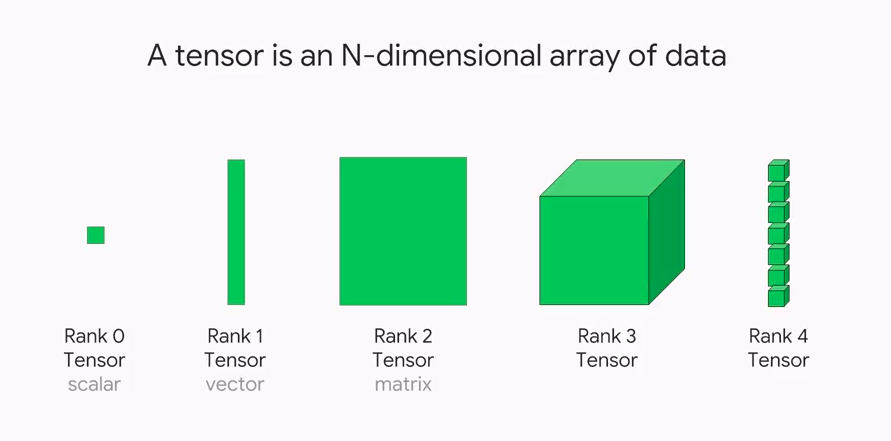


They can also be used to define the operations associated with their space (e.g. - a Tensor product)

$$ \Large T^{i_k}_j ⊗ t_{ik}$$

We won't focus on tensor algebra here, but if you want to know more, <a href = "https://www.youtube.com/watch?v=f5liqUk0ZTw">this video</a> and <a href = "https://www.youtube.com/watch?v=L35fFDpwIM4&ab_channel=StatQuestwithJoshStarmer">this video</a> is a great starting point.


### Visualizing the ranks

In [1]:
from sklearn.datasets import make_moons
from matplotlib import pyplot as plt
import numpy as np
import pandas as pd

In [2]:
scalar = np.array(6)
vector = np.array([1,2])
matrix = np.ones((2,2))
high_dim_tensor = np.ones((2,3,4))

print(f'rank = {scalar.ndim}, shape =  {scalar.shape}')
print(f'rank = {vector.ndim}, shape =  {vector.shape}')
print(f'rank = {matrix.ndim}, shape =  {matrix.shape}')
print(f'rank = {high_dim_tensor.ndim}, shape =  {high_dim_tensor.shape}')

rank = 0, shape =  ()
rank = 1, shape =  (2,)
rank = 2, shape =  (2, 2)
rank = 3, shape =  (2, 3, 4)


Rank 3 tensors can easily be respresented with the cartesean coordinates (x, y, z).

This has been a simplified representation so far.

In [3]:
high_dim_tensor

array([[[1., 1., 1., 1.],
        [1., 1., 1., 1.],
        [1., 1., 1., 1.]],

       [[1., 1., 1., 1.],
        [1., 1., 1., 1.],
        [1., 1., 1., 1.]]])

For ANNs, it's easier to think of tensors as objects that contain both data and operations.

## Tensorflow and Keras

Tensorflow is the platform we use to work with neural networks. It uses dataflow graphs (think about back and forward propagation). It's written in Cuda (a parallel computing platform working on GPUs) and C++ for performance; however, it mainly supports the Python API.

<a href = "https://keras.io/about/">Keras</a> is a deep learning API written in Python, running on top of the machine learning platform TensorFlow. It was developed with a focus on enabling fast experimentation.

To understand how computational graphs work for backpropagation: https://colah.github.io/posts/2015-08-Backprop/

## Working with Tensorflow

In [4]:
X, y = make_moons(n_samples = 200, 
                  noise = 0.1,
                  random_state = 42
                 )

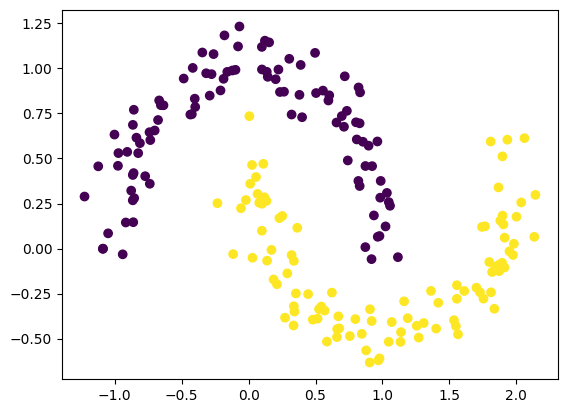

In [5]:
plt.scatter(X[:, 0], X[:, 1], c = y)

In [6]:
X  # contains two features for every observation

array([[-1.04942573e+00,  8.44426315e-02],
       [ 9.22817545e-01,  4.57488507e-01],
       [ 6.56786593e-01,  6.99596694e-01],
       [ 1.18894020e+00, -3.86528073e-01],
       [ 2.89264549e-01, -1.37744892e-01],
       [ 2.51685082e-01,  1.81006054e-01],
       [-6.68120991e-01,  8.22265447e-01],
       [ 1.55626644e+00, -2.03445580e-01],
       [ 1.87213538e+00, -1.25335230e-01],
       [ 1.43229273e-01,  9.53267512e-01],
       [-4.35091327e-01,  7.43738050e-01],
       [ 1.91161702e+00, -1.05146485e-01],
       [ 1.53432590e+00, -3.97547101e-01],
       [-8.24879535e-01,  5.29607749e-01],
       [ 1.88043395e+00,  1.54681644e-01],
       [ 1.87043050e+00, -9.01427936e-02],
       [-6.84180156e-02,  1.23271872e+00],
       [ 1.04680086e+00, -5.17441448e-01],
       [-1.00198756e+00,  6.32750117e-01],
       [-4.23980382e-01,  7.45855239e-01],
       [ 3.38030046e-01, -6.83719318e-02],
       [ 8.96478204e-01,  5.70936879e-01],
       [ 9.69901385e-01, -6.20552828e-01],
       [-8.

In [7]:
y  # contains all observation's labels
# 0 means upper moon
# 1 means lower moon

array([0, 0, 0, 1, 1, 1, 0, 1, 1, 0, 0, 1, 1, 0, 1, 1, 0, 1, 0, 0, 1, 0,
       1, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 1, 1, 1, 1, 1, 0, 0, 1, 0, 0,
       1, 1, 0, 0, 1, 0, 1, 1, 0, 1, 1, 0, 1, 0, 1, 0, 1, 0, 0, 0, 0, 1,
       0, 1, 0, 1, 0, 1, 1, 0, 1, 1, 0, 1, 1, 1, 0, 0, 0, 1, 1, 0, 1, 0,
       1, 0, 0, 1, 1, 0, 0, 1, 1, 0, 0, 1, 0, 0, 1, 1, 1, 1, 0, 0, 1, 1,
       1, 0, 1, 1, 0, 1, 0, 0, 1, 0, 0, 1, 1, 1, 0, 0, 1, 1, 0, 0, 1, 0,
       0, 1, 0, 1, 0, 1, 0, 1, 1, 1, 1, 0, 0, 0, 0, 1, 0, 0, 1, 1, 0, 0,
       0, 0, 1, 1, 0, 0, 1, 1, 1, 1, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 1, 1,
       1, 0, 1, 1, 0, 0, 1, 1, 1, 1, 0, 1, 0, 0, 1, 1, 0, 1, 0, 1, 0, 0,
       1, 1], dtype=int64)

## Building an Artificial Neural Network with Keras

* 1. Configuration

    * The network architecture, how many neurons, layers, which activation functions, etc.

* 2. Compilation
    
    * Optimizers, metrics, and loss function are decided at this step.

* 3. Fitting

    * This is where the number of iteration (epochs) and batch size are specified.
    
- 4. Evaluate

- 5. Make predictions

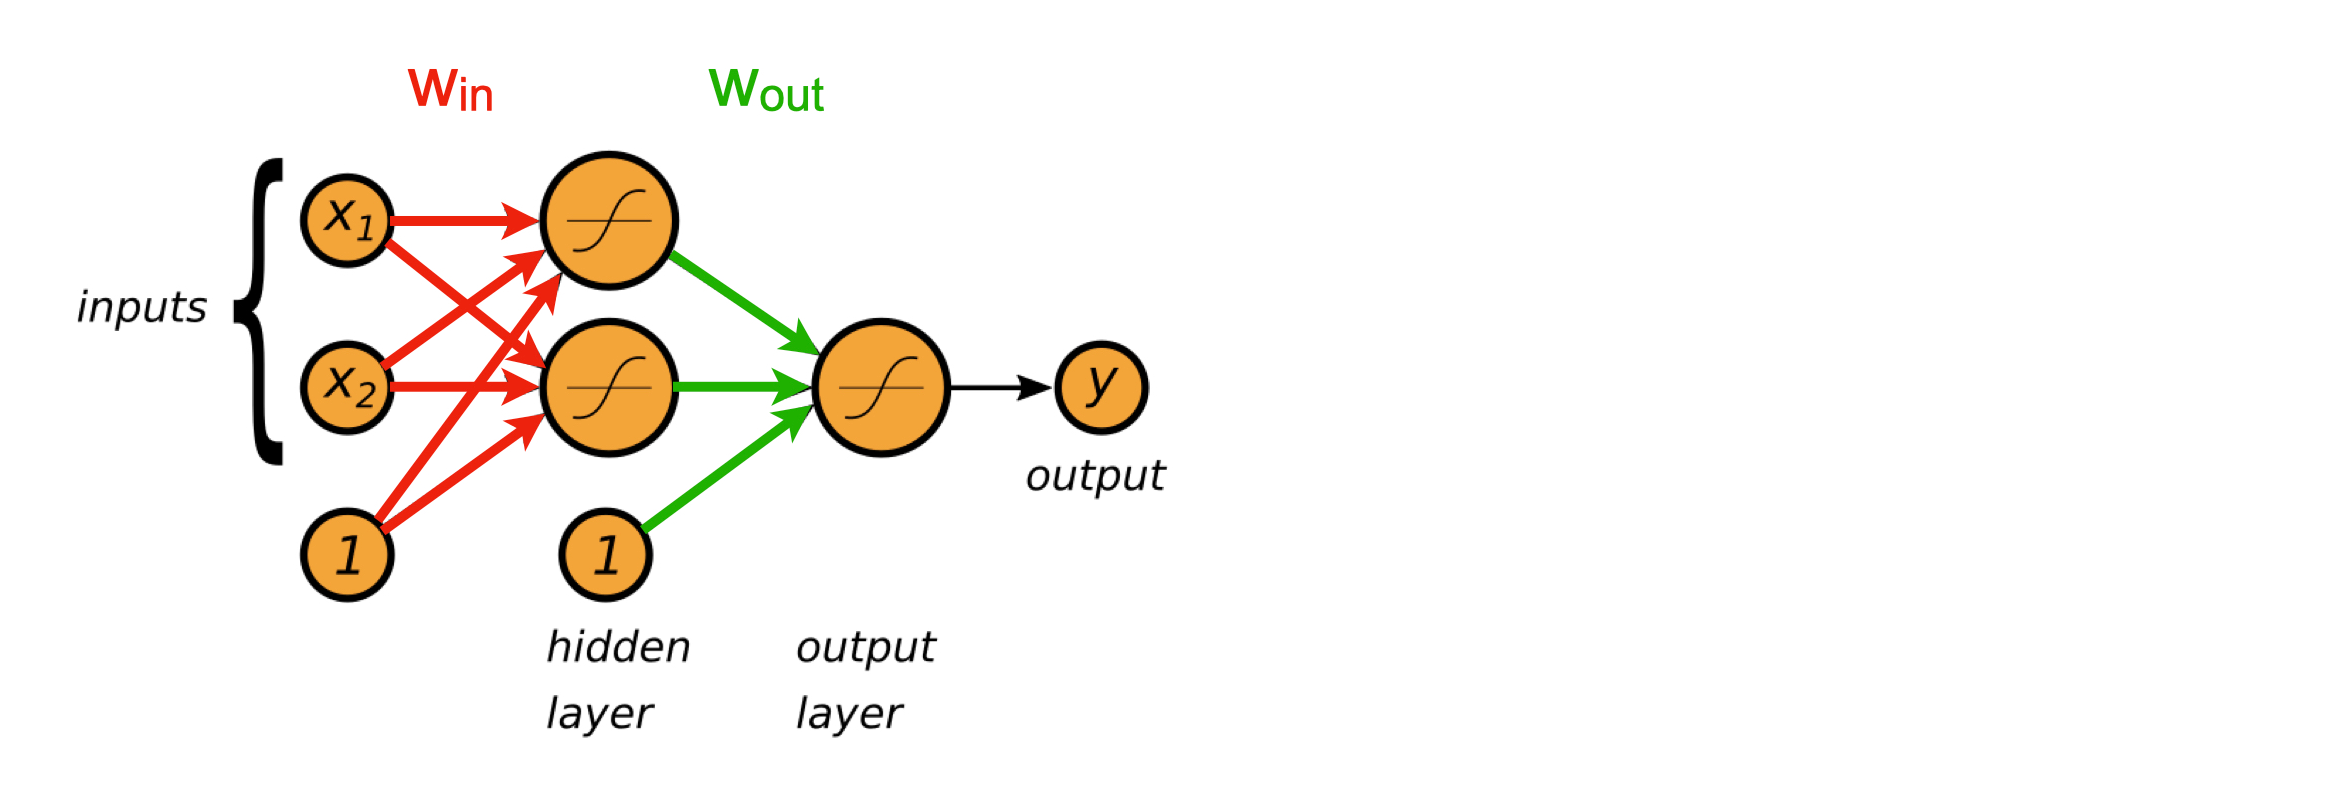

In [8]:
from tensorflow import keras
from tensorflow.keras import backend as K
# in case your system is not configured to support GPUs, you might get a warning

### 1. Configuration

Individual layers that map inputs to the targets are defined one by one.

You need to choose:
- how many layers;
- the **type of layer** (Dense, Convoluted, MaxPool...);
- the **number of neurons** (units) in each layer;
- the **activation function** (Sigmoid, ReLu..., can be also non-linear);
- optional: a **name** for the layer.

For some additional info on configurations and layer types: https://towardsdatascience.com/four-common-types-of-neural-network-layers-c0d3bb2a966c

In [9]:
# clears the compiler in C++
K.clear_session()

In [10]:
model = keras.models.Sequential() # initialize the model

**To restart a model you need to run the above again.**

Don't forget to K.clear_session() before configuiring a new model!!

**Let's define the first layer**
- dense layer: *all* inputs are passed to *all* neurons. You can think of this as a completely linear operation with the inputs. The dense layers get their biases and initial weights automatically, (unless you set it yourself as a hyperparameter).
- units: number neurons
- input_dim: number of features (how many columns? input dimensions are the $x_1$ and $x_2$. We need it for the input layer, and doesn't include the batch size). Input shape is the shape of a single data point. The network doesn't care how many data points it receives (it's going to get different number of data points among training and testing). 
- activation function, in this example will be a sigmoid
- name, to be able to identify the layer lateron

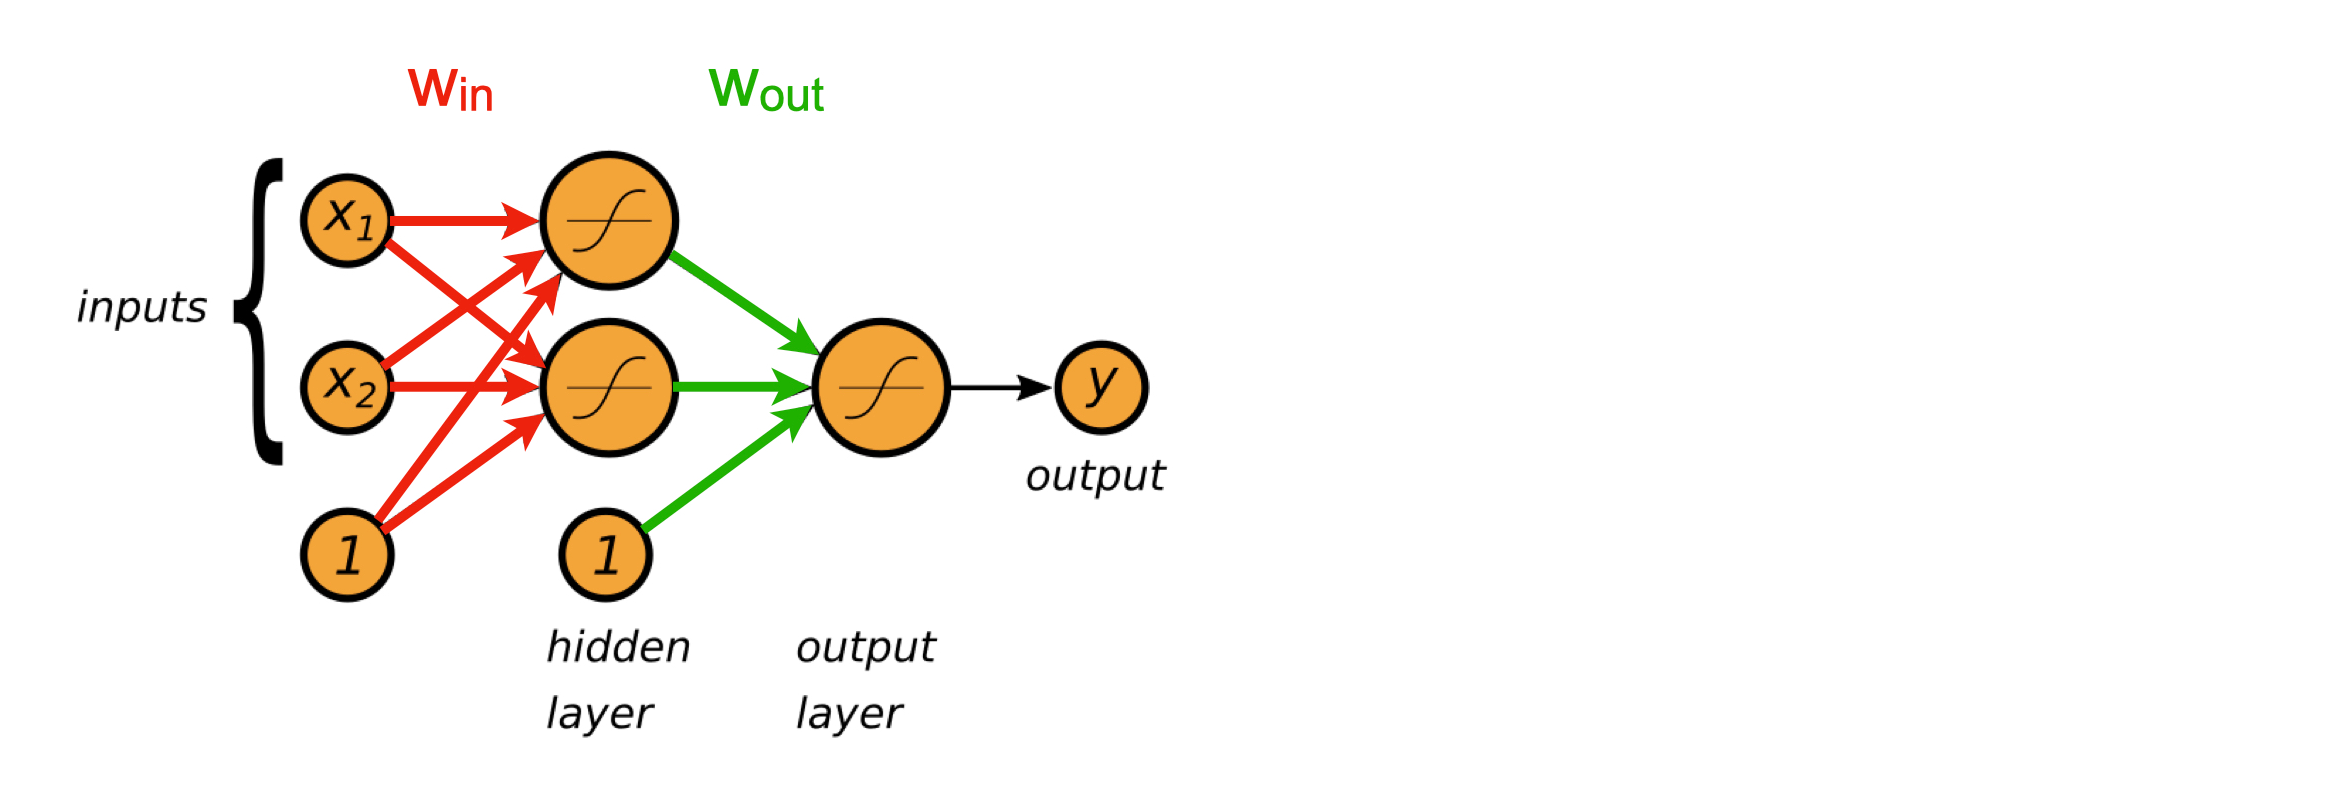

In [11]:
model.add(keras.layers.Dense(input_dim = 2, # only needed for the first layer
                            units = 2,      # number of neurons
                            activation = keras.activations.sigmoid,
                            name= 'hidden_layer'))

In [12]:
# To check the model so far
model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 hidden_layer (Dense)        (None, 2)                 6         
                                                                 
Total params: 6 (24.00 Byte)
Trainable params: 6 (24.00 Byte)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________


6 parameters, because there are 2x 2 weights and 2 biases.

**And now the second layer**

In [13]:
model.add(keras.layers.Dense(units = 1,
                            activation = keras.activations.sigmoid,
                            name= 'output_layer'))

In [14]:
model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 hidden_layer (Dense)        (None, 2)                 6         
                                                                 
 output_layer (Dense)        (None, 1)                 3         
                                                                 
Total params: 9 (36.00 Byte)
Trainable params: 9 (36.00 Byte)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________


#### Where do the 9 parameters come from?

Think about the architecture.

In the first layer, 2 inputs (same for each) and 1 separate bias for each neuron. 

In the second layer, the weights for the 2 outputs of the 1st layer and 1 bias goes to the remaining neuron.

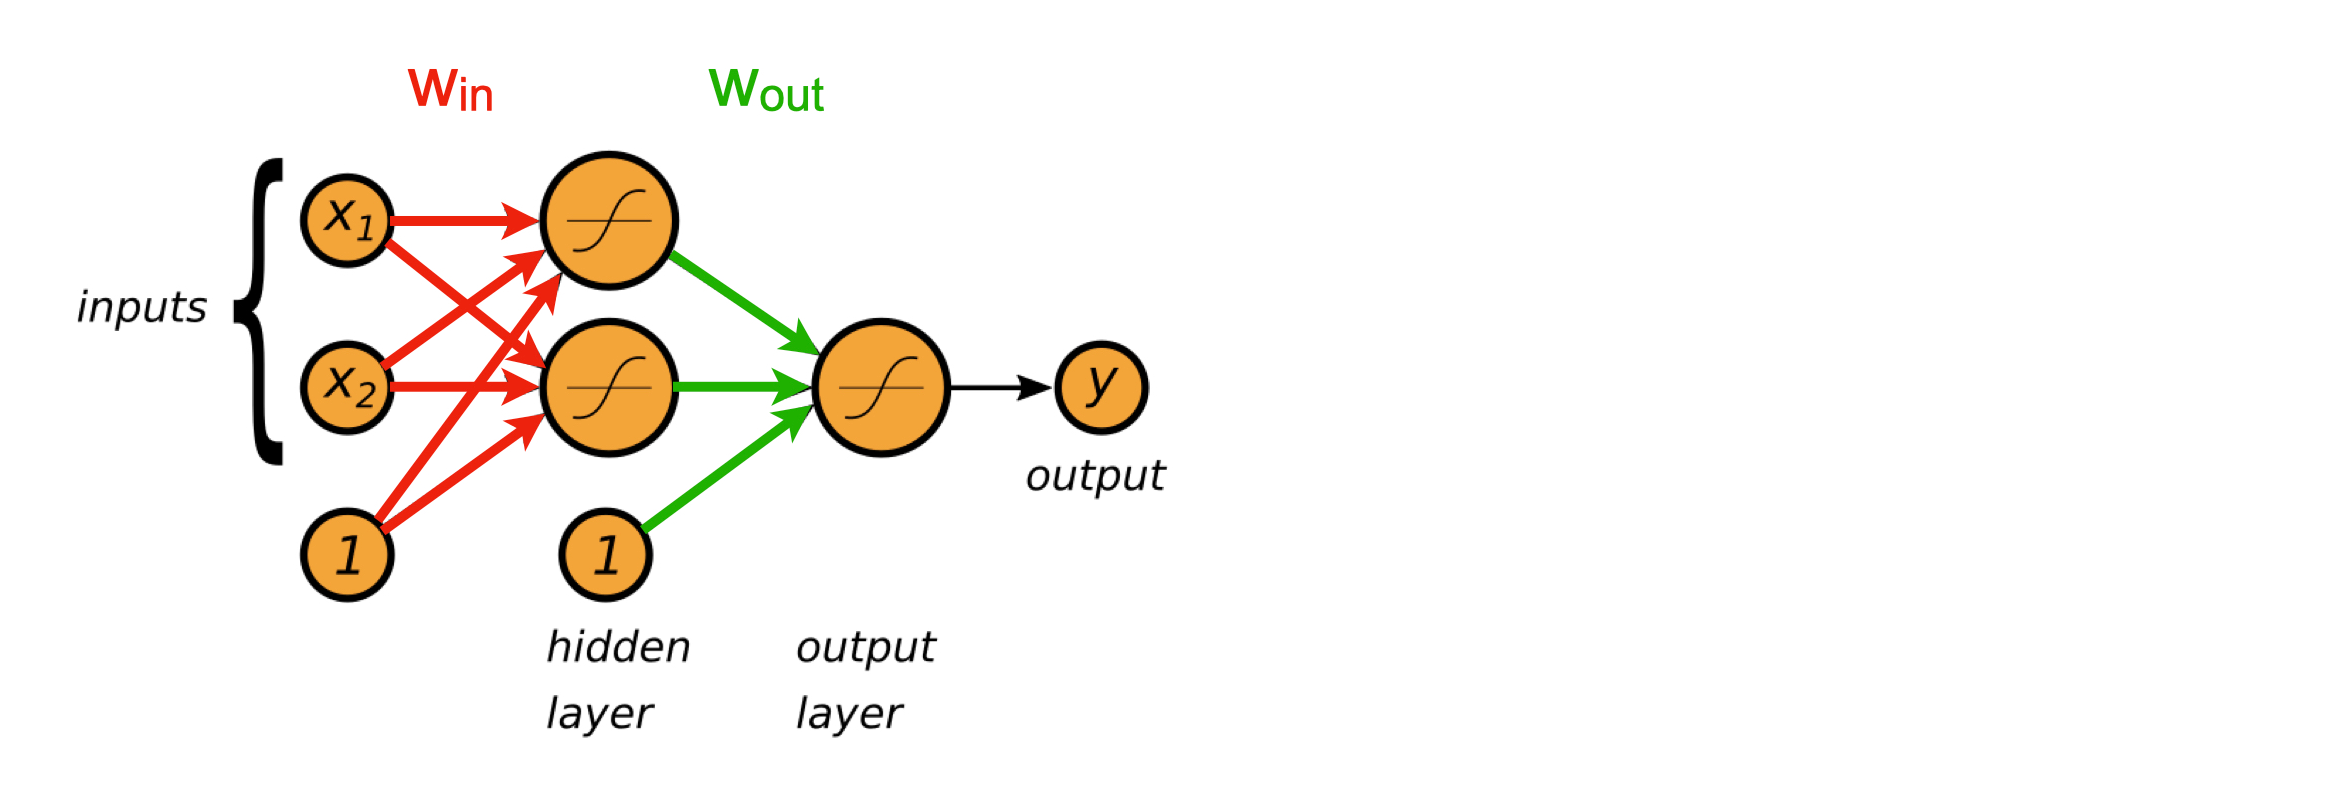

Note: So far we've only dealt with dense layers. We will also discuss convolutional layers this week.

## 2. Compilation

This is where Keras actually communicates with TensorFlow and creates what's called a 'computation graph'. Keras is compiling our model into a very abstract form that is implemented in C++.

One caveat about compile -- if you run this piece of code more than once in a single session, Keras will get confused.


Running Keras in Jupyter is fine, but **remember**:

    `from tensforflow.keras import backend as K
     K.clear_session()` 

You should do this everytime you use Keras, because it will clear the memory of the previously compiled model every time.

In the compilation, we need to choose:
- **optimizer**, choosing the right one can speed up the training (do you remeber gradient descent?). A popular one is ADAM, you also need to specify the learning rate (also alled _step size_ or _alpha_);
- **loss function**, paramether that we want to minimize, for this example (binary classification) we will use the _binary_crossentrophy_;
- **metrics**, we can specify other matrics we want to keep track, for example _binary_accuracy_;

In [15]:
K.clear_session() # don't forget to clear precious sessions!!
model.compile(
              optimizer = keras.optimizers.Adam(learning_rate = 0.3),
              loss = keras.losses.binary_crossentropy,
              metrics = [keras.metrics.binary_accuracy] 
             )

https://keras.io/api/optimizers/adam/
    
ADAM optimises the network using a stochastic gradient descent. It is mentioned in the documentation that it works well if the sample size is larger in comparison to the number of parameters.

**Reminder: Stochastic gradient descent economically estimates the gradient of the loss function by not using the complete dataset.**

## 3. Fit the model to the training data

In the Fit, we split the data to train them faster, we need to choose:
- **epochs**: how many time we want to run the network;  
 An epoch consists of several iterations for a complete forward+backward propagation
- **batch_size**: number of observations per gradient update;  
 The sample size (no. of observations) used for one iteration. This reduces computational effort instead of using all samples => stochastic gradient
- **validation_split**: fraction of samples used as validation set (like train_test_split in sklearn);

In [16]:
model_history = model.fit(
                 X,
                 y,
                 epochs = 100, 
                 batch_size = 32, 
                 validation_split = 0.3)

Epoch 1/100


5/5 [==============================] - 1s 109ms/step - loss: 0.5971 - binary_accuracy: 0.7214 - val_loss: 0.4586 - val_binary_accuracy: 0.8333
Epoch 2/100
5/5 [==============================] - 0s 16ms/step - loss: 0.4278 - binary_accuracy: 0.8286 - val_loss: 0.3629 - val_binary_accuracy: 0.8167
Epoch 3/100
5/5 [==============================] - 0s 11ms/step - loss: 0.3453 - binary_accuracy: 0.8571 - val_loss: 0.3321 - val_binary_accuracy: 0.8333
Epoch 4/100
5/5 [==============================] - 0s 9ms/step - loss: 0.3057 - binary_accuracy: 0.8571 - val_loss: 0.3269 - val_binary_accuracy: 0.8500
Epoch 5/100
5/5 [==============================] - 0s 10ms/step - loss: 0.3000 - binary_accuracy: 0.8500 - val_loss: 0.3285 - val_binary_accuracy: 0.7833
Epoch 6/100
5/5 [==============================] - 0s 9ms/step - loss: 0.3058 - binary_accuracy: 0.8786 - val_loss: 0.3289 - val_binary_accuracy: 0.8167
Epoch 7/100
5/5 [==============================] - 0s 9ms/step - loss: 0.29

And the output values?  
- *loss* &rarr; Like in classical ML, the value which should be zero at best.
- *binary_accuracy* &rarr; like in classical ML, the percentage of correctly classified labels
- *val_loss* &rarr; "val" refers to the *test* portion of the input
- *val_bin_accuracy* &rarr; again the accuracy but not for train but for test data

## 4. Evaluate the model

This step is the same than for other ML models. Simply observe the trend of the loss and accuracy (or any other metric you choose in the compile step). 

In [17]:
# model_history.history is a dictionary
model_history.history.keys()

dict_keys(['loss', 'binary_accuracy', 'val_loss', 'val_binary_accuracy'])

What's the length of the dictionary? How many entries does every metric/key has?

In [18]:
pd.DataFrame(model_history.history).shape

(100, 4)

Let's plot the evaluation metrics over training epocs to evaluate the model

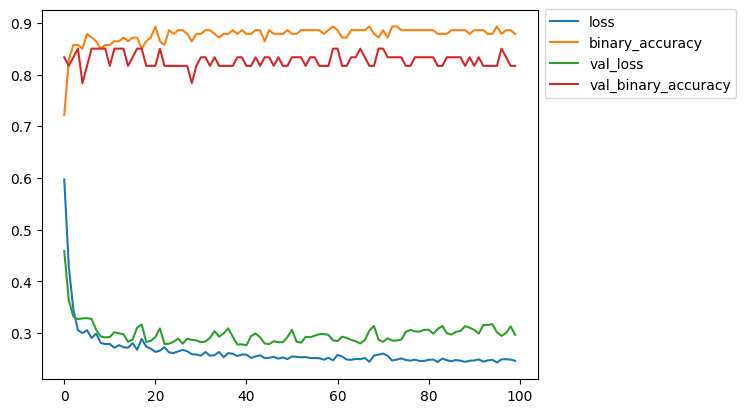

In [19]:
pd.DataFrame(model_history.history).plot()
plt.legend(bbox_to_anchor = [1, 1.02])

How is the model? Why there are two curves for loss and two for the accuracy? 

In [20]:
# Print out the score
score = model.evaluate(X, y, verbose=0)
print(score, model.metrics_names)

[0.25979188084602356, 0.8650000095367432] ['loss', 'binary_accuracy']


## 5. Make prediction

We are first building new data using again `make_moons` but with a different random state, then we predict the class using the model we just developed. Finally, we compare the results. 

In [21]:
# make new X and new y
new_X, new_y = make_moons(n_samples = 200, 
                  noise = 0.1,
                  random_state = 2025 # different random state
                 )

In [22]:
# predict y_hat using the model previously defined
y_hat=model.predict(new_X)

7/7 [==============================] - 0s 2ms/step


In [23]:
y_hat.shape

(200, 1)

Text(0.5, 1.0, 'predicted classes')

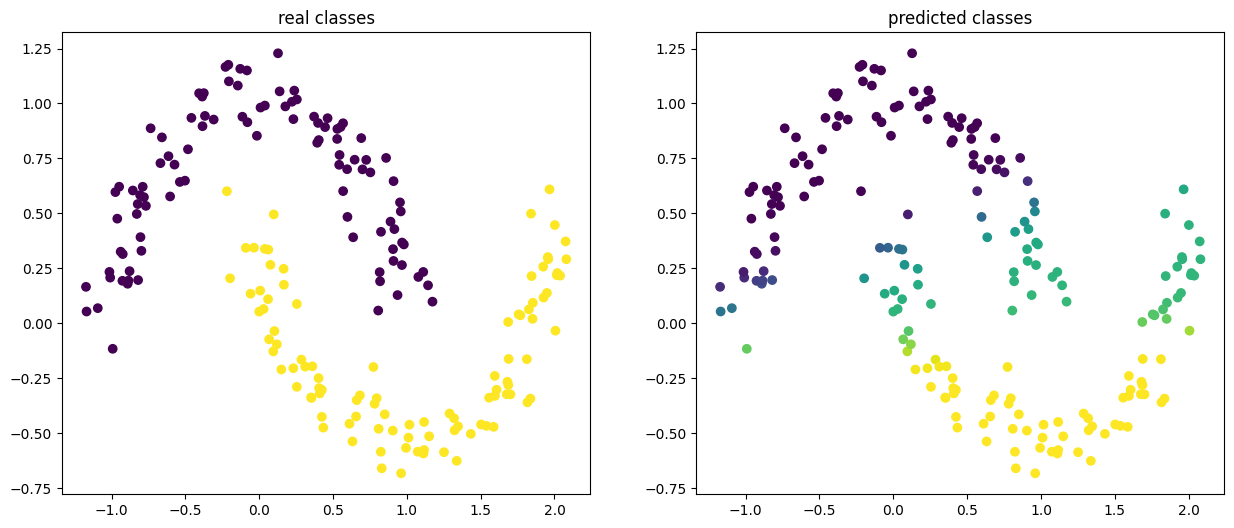

In [24]:
# Let's plot the results
f = plt.figure(figsize=(15,6))
ax1 = f.add_subplot(121)  # row 1, col 2, index 1
ax2 = f.add_subplot(122)
x = np.linspace(0,4,1000)
ax1.scatter(new_X[:,0], new_X[:,1], c = new_y)
ax1.set_title('real classes')

ax2.scatter(new_X[:,0], new_X[:,1], c = y_hat)
ax2.set_title('predicted classes')

In [25]:
y_hat

array([[0.10064463],
       [0.65710974],
       [0.01550031],
       [0.01790722],
       [0.6412163 ],
       [0.01459458],
       [0.01483131],
       [0.9997644 ],
       [0.9997944 ],
       [0.01839089],
       [0.35007933],
       [0.99979585],
       [0.01457019],
       [0.32831654],
       [0.63501084],
       [0.9989667 ],
       [0.990498  ],
       [0.01529793],
       [0.65330076],
       [0.64878505],
       [0.01477172],
       [0.01738365],
       [0.64577156],
       [0.9998087 ],
       [0.9997441 ],
       [0.9998115 ],
       [0.6190227 ],
       [0.99979067],
       [0.01474694],
       [0.5708121 ],
       [0.02954561],
       [0.01457322],
       [0.15226273],
       [0.9998084 ],
       [0.02986053],
       [0.01656344],
       [0.01520657],
       [0.9963707 ],
       [0.6183425 ],
       [0.01623289],
       [0.86222214],
       [0.99943185],
       [0.01509084],
       [0.9997766 ],
       [0.6586831 ],
       [0.638805  ],
       [0.9994661 ],
       [0.999

What are these predictions? Regression values or something else?

Remember we defined our model with accuracy as we wanted to distinguish between the two classes in the data. Since this is a classification, we have probabilities.

In [26]:
print(model_history.history.keys())
print(model_history.history['val_loss'])

dict_keys(['loss', 'binary_accuracy', 'val_loss', 'val_binary_accuracy'])
[0.4586434066295624, 0.3629303574562073, 0.33209457993507385, 0.3269400894641876, 0.3285020887851715, 0.3289465010166168, 0.32738879323005676, 0.3065665662288666, 0.29357627034187317, 0.29172447323799133, 0.29245173931121826, 0.30186837911605835, 0.2994760274887085, 0.2981739640235901, 0.28341734409332275, 0.28739288449287415, 0.3107434809207916, 0.31647947430610657, 0.2829235792160034, 0.2850337624549866, 0.29239919781684875, 0.30909663438796997, 0.27905189990997314, 0.2795262038707733, 0.28315430879592896, 0.2893955111503601, 0.279625803232193, 0.2891676723957062, 0.28699639439582825, 0.2859615981578827, 0.2824971079826355, 0.28382739424705505, 0.2907971739768982, 0.3038085103034973, 0.2932746708393097, 0.2995525896549225, 0.30915457010269165, 0.2929665148258209, 0.27786704897880554, 0.2783009111881256, 0.27649205923080444, 0.29420384764671326, 0.2992887496948242, 0.29176679253578186, 0.2799462080001831, 0.2788

### BONUS 1: Save and Load your model

In [27]:
# You can save  and load your model
from tensorflow.keras.models import load_model

model.save("model_moons.keras")
moons_model = load_model("model_moons.keras") # legacy version: "mode_moons.h5"

We could use model_moons.h5 lateron without any training to make predictions on new data with `load_model("model_moons.keras")`

### BONUS 2: Nice to know: A more compact way to build your ANN with keras.layers

There are many many more layer options than what we are using here. 

Checkout this link to learn more: https://www.tensorflow.org/api_docs/python/tf/keras/layers

In [28]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Activation

In the below, you only need to tell the input shape in the first layer, (2 inputs, 2 outputs). It might feel familiar if you think about pipelines.

In [29]:
K.clear_session()

model = Sequential([
    Dense(2, input_shape=(2,)),
    Activation('sigmoid', name = 'sigmoid_1'),
    Dense(1), 
    Activation('sigmoid', name = 'sigmoid_2'),
])

In [30]:
model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense (Dense)               (None, 2)                 6         
                                                                 
 sigmoid_1 (Activation)      (None, 2)                 0         
                                                                 
 dense_1 (Dense)             (None, 1)                 3         
                                                                 
 sigmoid_2 (Activation)      (None, 1)                 0         
                                                                 
Total params: 9 (36.00 Byte)
Trainable params: 9 (36.00 Byte)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________


Of course you still need to compile the model afterwards, etc.

## Exercise  
Try to extend the model with another layer and more units so that the two *new* half moons will be predicted more accurate.

In [31]:
K.clear_session()

model = Sequential([
    Dense(2, input_shape=(2,)),
    Activation('sigmoid', name = 'sigmoid_1'),
    Dense(1), 
    Activation('sigmoid', name = 'sigmoid_2'),
])